# Explore Saved Results

Use [run_broadcast.ipynb](run_broadcast.ipynb) to plan, launch, collect and plot hardware campaigns or repeat the restored Monte Carlo convergence study. This notebook provides additional saved-data exploration. Historical data and campaign results load together; figures save only as PNG. See [README](README.md) for setup and interpretation.


## Manuscript Figures 3–6

Run the following cell **on its own** from the project root. It reads the saved data and displays and exports all four manuscript figures. It does not collect new data. Edit `PLOT_RC`, `EXPORT`, and `FIGURE_3` through `FIGURE_6` at the top, then rerun. Sizes, fonts, colors, markers, lines, axes, grids, legends, the crossover inset, delay confidence bands, scaling offsets/ranges, and the convergence reference are exposed; the plotting code is in the same cell for further changes.

The defaults combine the two historical 121-point opt3 delay sweeps with the three new delay repeats, include historical and campaign scaling observations, and show the historical convergence summary alongside saved seeds 1–4. Every delay job/phase and scaling observation stays separate. Delay bands are conditional 95% Wilson shot intervals; scaling bars span receiver minimum–maximum and are not confidence intervals.

`SAVE_MANUSCRIPT_FIGURES = True` exports the four `figure_03_...png` through `figure_06_...png` files into both `manuscript/` and `figures/`, plus source hashes and plotting settings in `figures/manuscript_sources.json`. Set it to `False` to preview. The manuscript already references these filenames; rebuild `manuscript/apstemplate.tex` after exporting. If you change source selections or statistical displays, revise the corresponding captions too. The older historical CLI uses different filenames.

Figure objects remain available in `manuscript_figures[3]` through `[6]`. Source selections use local paths; the complete campaign bundles are needed to reproduce these plots on another machine.


Figure 3: manuscript/figure_03_qec_crossover.png
Figure 3: figures/figure_03_qec_crossover.png


Figure 4: manuscript/figure_04_delay_repeats.png


Figure 4: figures/figure_04_delay_repeats.png
Figure 5: manuscript/figure_05_hardware_scaling.png


Figure 5: figures/figure_05_hardware_scaling.png
Figure 6: manuscript/figure_06_sampling_convergence.png


Figure 6: figures/figure_06_sampling_convergence.png
Figure 3


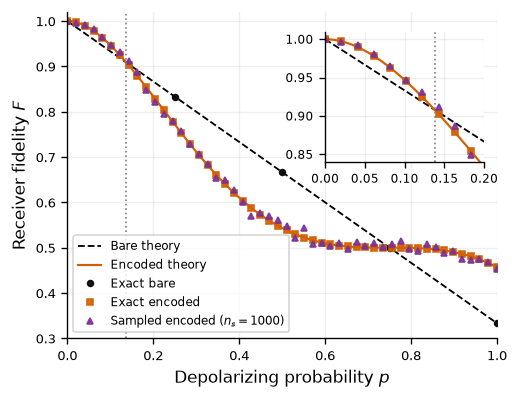

Figure 4


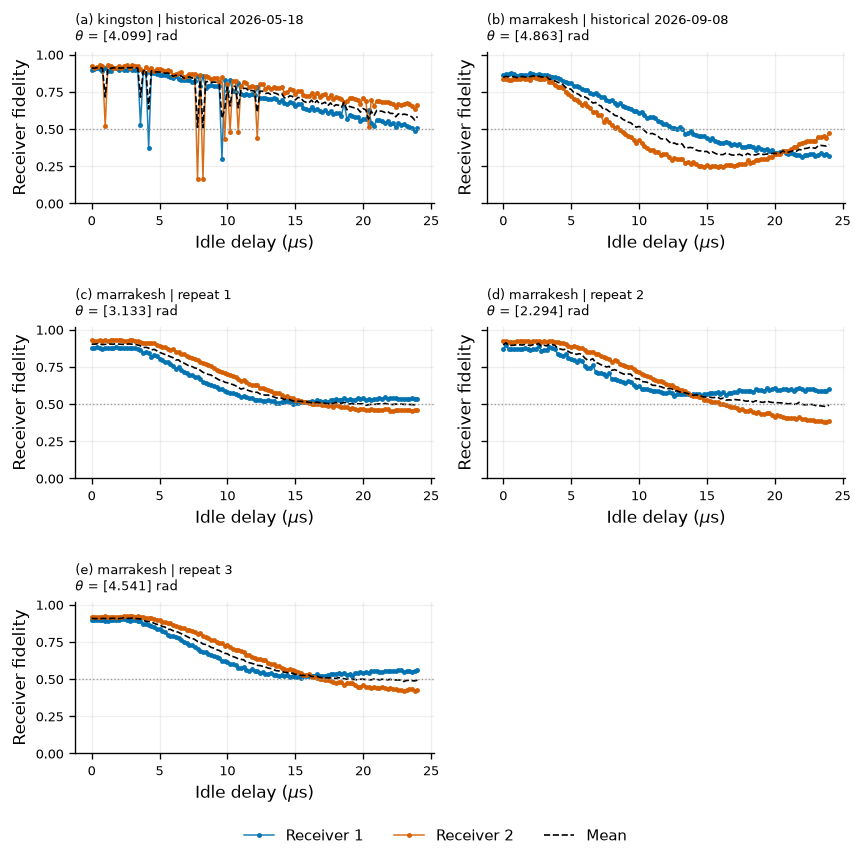

Figure 5


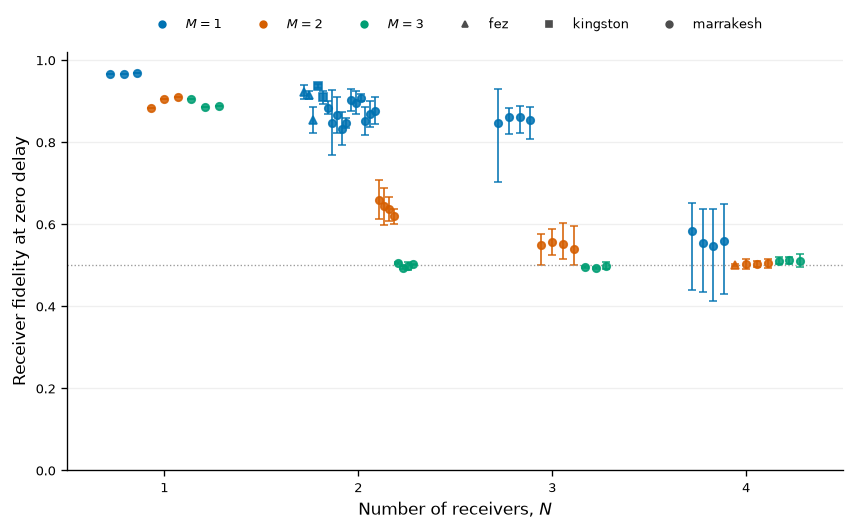

Figure 6


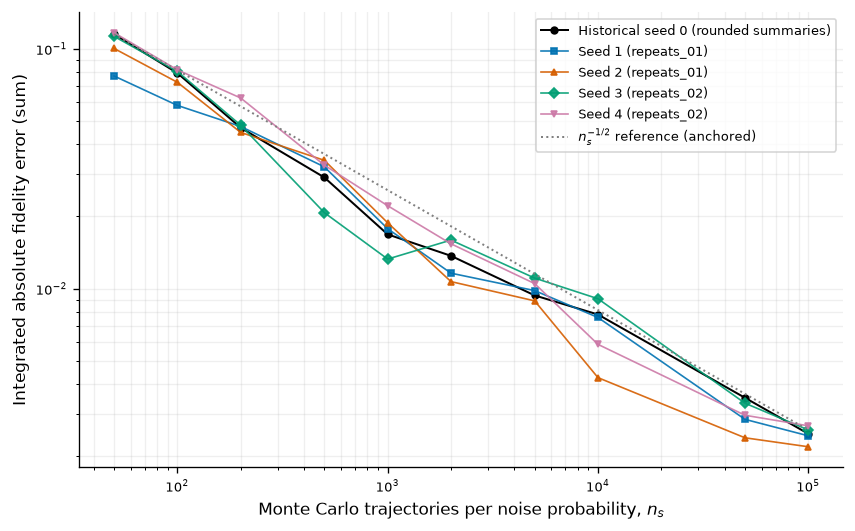

Figure 4: 5 separate delay panels; Figure 5: 55 separate observations; Figure 6: historical seed 0 plus saved seeds [1, 2, 3, 4].


In [1]:
# Run this cell on its own. Edit the settings below, then rerun to update all four figures.
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from IPython.display import display

from broadcasting.analysis import delay_axis, joint_success_statistics, wilson_interval
from broadcasting.convergence import load_historical_convergence
from broadcasting.plotting import hardware_scaling_points, save_figure
from broadcasting.results import load_run
from broadcasting.simulation import logical_error_polynomial
from broadcasting.validation import dedupe_by_job
from scripts.analyze_saved_hardware import load_hardware_runs
from scripts.figure_sources import load_source, source_manifest

ROOT = Path.cwd().resolve()
if not (ROOT / "broadcasting").is_dir():
    raise RuntimeError("Run this cell from the Broadcasting project root.")

# -------------------------- EDIT PLOTTING SETTINGS HERE --------------------------
SAVE_MANUSCRIPT_FIGURES = True  # False previews without changing exported files.
OUTPUT_DIRS = [ROOT / "manuscript", ROOT / "figures"]
PROVENANCE_PATH = ROOT / "figures" / "manuscript_sources.json"
EXPORT = dict(dpi=300, bbox_inches="tight", pad_inches=0.06,
              facecolor="white", transparent=False, strip_titles=True)
# Any Matplotlib rcParam can be added here. Changes stay local to this cell.
PLOT_RC = {
    "figure.dpi": 120, "font.family": "DejaVu Sans", "font.size": 9,
    "axes.labelsize": 10, "axes.titlesize": 10, "axes.linewidth": 0.8,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "lines.linewidth": 1.2, "lines.markersize": 4,
    "axes.spines.top": False, "axes.spines.right": False,
}
FIGURE_3 = {
    "filename": "figure_03_qec_crossover.png", "figsize": (4.4, 3.4),
    # Ordered: exact bare, exact encoded, sampled encoded. Each retains its native p grid.
    "sources": ["results/run_20260422_110316.json", "results/run_20260426_170827.json",
                "results/run_20260427_114317.json"],
    "theory_p_range": (0, 1), "theory_points": 500,
    "bare_theory": dict(color="black", linestyle="--", linewidth=1.1, label="Bare theory"),
    "encoded_theory": dict(color="#D55E00", linestyle="-", linewidth=1.3, label="Encoded theory"),
    "data_styles": [dict(marker="o", color="black", label="Exact bare"),
                    dict(marker="s", color="#D55E00", label="Exact encoded"),
                    dict(marker="^", color="#7B3294", label="Sampled encoded ($n_s={n_samples}$)")],
    "data_common": dict(linestyle="none", markersize=3.5, alpha=0.9),
    "show_crossover": True, "crossover_style": dict(color="0.5", linestyle=":", linewidth=1),
    "show_inset": True, "inset_bounds": [0.60, 0.54, 0.37, 0.40],
    "inset_axes": dict(xlim=(0, 0.20), ylim=(0.84, 1.01)),
    "inset_ticks": dict(axis="both", labelsize=7),
    "axes": dict(xlabel="Depolarizing probability $p$", ylabel="Receiver fidelity $F$",
                 xlim=(0, 1), ylim=(0.3, 1.02), xscale="linear", yscale="linear"),
    "grid": dict(visible=True, alpha=0.2),
    "legend": dict(loc="lower left", fontsize=7, frameon=True),
    "layout": dict(pad=1.1),
}
FIGURE_4 = {
    "filename": "figure_04_delay_repeats.png", "columns": 2, "panel_size": (3.6, 2.4),
    "sharey": True,
    # Two historical 121-point opt3 sweeps, followed by all three new delay repeats.
    "sources": ["results/run_20260518_120232.json", "results/run_20260908_153150_79eab41b.json",
                "campaigns/delay_01/results/repeat_000_m1_n2.json",
                "campaigns/delay_01/results/repeat_001_m1_n2.json",
                "campaigns/delay_01/results/repeat_002_m1_n2.json"],
    "receiver_colors": ["#0072B2", "#D55E00"],
    "receiver_style": dict(marker="o", markersize=2, linestyle="-", linewidth=0.9, alpha=0.9),
    "receiver_label": "Receiver {receiver}",
    "show_intervals": True, "confidence": 0.95, "interval_style": dict(alpha=0.18, linewidth=0),
    "show_mean": True, "mean_style": dict(color="black", linestyle="--", linewidth=1, label="Mean"),
    "baseline": 0.5, "baseline_style": dict(color="0.6", linestyle=":", linewidth=0.8),
    # None uses the archived dt conversion (microseconds), or native dt if unknown.
    "xlabel": None,
    "axes": dict(ylabel="Receiver fidelity", xlim=None, ylim=(0, 1.02),
                 xscale="linear", yscale="linear"),
    "panel_label": "({letter}) {backend} | {identity}\n$\\theta$ = [{phases}] rad",
    "panel_text": dict(x=0, y=1.04, fontsize=8, va="bottom", ha="left"),
    "grid": dict(visible=True, alpha=0.2),
    "legend": dict(loc="lower center", bbox_to_anchor=(0.5, 0), ncol=3, frameon=False, fontsize=9),
    "layout": dict(pad=1.1, h_pad=2.2, w_pad=1.2, rect=(0, 0.045, 1, 1)),
}
FIGURE_5 = {
    "filename": "figure_05_hardware_scaling.png", "figsize": (7.2, 4.5),
    "source_dirs": ["results", "campaigns/scaling_01/results", "campaigns/delay_01/results"],
    # Optional exact filepath selection; None keeps every eligible opt3 tau=0 observation.
    "sources": None,
    "sender_colors": {1: "#0072B2", 2: "#D55E00", 3: "#009E73"},
    "backend_markers": {"ibm_kingston": "s", "ibm_fez": "^", "ibm_marrakesh": "o"},
    "fallback_colors": ["#CC79A7", "#E69F00", "#56B4E9"],
    "fallback_markers": ["D", "v", "P", "X"],
    "horizontal_spread": 0.56,  # Full width around each integer N; zero disables offsets.
    "show_receiver_range": True,
    "point_style": dict(markersize=4.5, capsize=2.5, linewidth=1.1, alpha=0.85, linestyle="none"),
    "sender_label": "$M={sender}$", "backend_label": "{backend}",
    "backend_legend_color": "0.3",
    "baseline": 0.5, "baseline_style": dict(color="0.6", linestyle=":", linewidth=0.8),
    "axes": dict(xlabel="Number of receivers, $N$", ylabel="Receiver fidelity at zero delay",
                 xlim=None, ylim=(0, 1.02), xscale="linear", yscale="linear"),
    "xticks": None,  # None uses the integer receiver counts.
    "grid": dict(visible=True, axis="y", alpha=0.2),
    "legend": dict(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=6, frameon=False, fontsize=8),
    "layout": dict(pad=1.1),
}
FIGURE_6 = {
    "filename": "figure_06_sampling_convergence.png", "figsize": (7.2, 4.5),
    "archive_dir": "results/convergence", "batches": ["repeats_01", "repeats_02"], "seeds": [1, 2, 3, 4],
    "show_historical": True,
    "historical_style": dict(color="black", marker="o", markersize=4, linewidth=1.2,
                             label="Historical seed 0 (rounded summaries)"),
    "seed_colors": {1: "#0072B2", 2: "#D55E00", 3: "#009E73", 4: "#CC79A7"},
    "seed_markers": {1: "s", 2: "^", 3: "D", 4: "v"},
    "repeat_style": dict(linestyle="-", linewidth=1, markersize=4, alpha=0.9),
    "repeat_label": "Seed {seed} ({batch}){partial}",
    "show_reference": True, "reference_exponent": -0.5,
    "reference_anchor_index": 0, "reference_multiplier": 1.0,
    "reference_style": dict(color="0.5", linestyle=":", linewidth=1.2,
                            label="$n_s^{-1/2}$ reference (anchored)"),
    "axes": dict(xlabel="Monte Carlo trajectories per noise probability, $n_s$",
                 ylabel="Integrated absolute fidelity error (sum)",
                 xlim=None, ylim=None, xscale="log", yscale="log"),
    "grid": dict(visible=True, which="both", alpha=0.2),
    "legend": dict(loc="best", fontsize=8, frameon=True),
    "layout": dict(pad=1.1),
}
# ------------------------- RENDER FROM SAVED DATA ONLY -------------------------
# Plotting code is also in this cell for changes beyond the settings above.
_manifest = source_manifest()

def _read_figure_run(relative_path):
    return (load_source(relative_path, manifest=_manifest) if relative_path in _manifest["runs"]
            else load_run(ROOT / relative_path))

def _style_axis(ax, settings):
    properties = dict(settings["axes"])
    # Set scales before limits; passing None limits would disable autoscaling.
    ax.set_xscale(properties.pop("xscale", "linear"))
    ax.set_yscale(properties.pop("yscale", "linear"))
    ax.set(**{key: value for key, value in properties.items() if value is not None})
    ax.grid(**settings["grid"])

def _source_evidence(path):
    path = Path(path).resolve()
    relative = str(path.relative_to(ROOT)) if path.is_relative_to(ROOT) else str(path)
    return {"path": relative, "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
            "historical_overrides": _manifest["runs"].get(relative, {}).get("historical_overrides", {})}

# Close only this cell's previous figures when rerunning.
for _old_figure in globals().get("manuscript_figures", {}).values():
    plt.close(_old_figure)
manuscript_figures = {}
manuscript_sources = {}

with plt.rc_context(PLOT_RC):
    # Figure 3: exact and sampled crossover curves on their own saved grids.
    cfg = FIGURE_3
    crossover_runs = [_read_figure_run(path) for path in cfg["sources"]]
    if len(crossover_runs) != 3 or len(cfg["data_styles"]) != 3:
        raise ValueError("Figure 3 needs exact bare, exact encoded, and sampled encoded sources/styles.")
    for run, qec, backend in zip(crossover_runs, [False, True, True], ["aer_exact", "aer_exact", "aer_sampling"]):
        if ((run["M"], run["N"], run["sweep"]["axis"]) != (1, 2, "p")
                or run["use_qec"] != qec or run["backend"] != backend
                or not np.isclose(run["alpha"], crossover_runs[0]["alpha"])
                or not np.allclose(run["theta_samples"], crossover_runs[0]["theta_samples"])):
            raise ValueError("Figure 3 sources must have matching protocol/target settings and the stated simulation modes.")
    fig3, ax3 = plt.subplots(figsize=cfg["figsize"])
    inset3 = ax3.inset_axes(cfg["inset_bounds"]) if cfg["show_inset"] else None
    p = np.linspace(*cfg["theory_p_range"], cfg["theory_points"])
    for ax in [ax3] + ([inset3] if inset3 is not None else []):
        ax.plot(p, 1 - 2 * p / 3, **cfg["bare_theory"])
        ax.plot(p, 1 - 2 * logical_error_polynomial(p) / 3, **cfg["encoded_theory"])
        for run, style in zip(crossover_runs, cfg["data_styles"]):
            style = {**cfg["data_common"], **style}
            style["label"] = style["label"].replace("{n_samples}", str(run.get("n_samples")))
            ax.plot(run["sweep"]["values"], np.asarray(run["fidelities"]).mean(axis=1), **style)
        if cfg["show_crossover"]:
            ax.axvline((3 - np.sqrt(6)) / 4, **cfg["crossover_style"])
        ax.grid(**cfg["grid"])
    _style_axis(ax3, cfg)
    if inset3 is not None:
        inset3.set(**cfg["inset_axes"])
        inset3.tick_params(**cfg["inset_ticks"])
    ax3.legend(**cfg["legend"])
    fig3.tight_layout(**cfg["layout"])
    manuscript_figures[3] = fig3
    manuscript_sources[3] = [_source_evidence(ROOT / path) for path in cfg["sources"]]

    # Figure 4: separate panel per job/angle, with count-derived marginal intervals.
    cfg = FIGURE_4
    delay_runs = dedupe_by_job([_read_figure_run(path) for path in cfg["sources"]])
    traces = []
    for run in delay_runs:
        if (run["experiment_type"] != "hardware" or run.get("optimization_level") != 3
                or (run["M"], run["N"]) != (1, 2) or run.get("use_qec")
                or run["sweep"]["axis"] != "tau" or len(run["sweep"]["values"]) < 2 or not run.get("counts")):
            raise ValueError(f"Figure 4 needs unencoded opt3 M=1,N=2 delay records with counts: {run['filename']}")
        traces.extend((run, i, row) for i, row in enumerate(run["counts"]))
    if not traces or cfg["columns"] < 1:
        raise ValueError("Figure 4 needs at least one trace and one column.")
    columns = min(cfg["columns"], len(traces))
    rows = int(np.ceil(len(traces) / columns))
    fig4, axes4 = plt.subplots(rows, columns, squeeze=False, sharey=cfg["sharey"],
                              figsize=(columns * cfg["panel_size"][0], rows * cfg["panel_size"][1]))
    for index, (ax, (run, theta_index, counts)) in enumerate(zip(axes4.flat, traces)):
        scale, unit = delay_axis(run)
        order = np.argsort(run["sweep"]["values"])
        tau = scale * np.asarray(run["sweep"]["values"])[order]
        stats = [joint_success_statistics(counts[i], run["N"]) for i in order]
        local = np.asarray([item["local_fidelities"] for item in stats])
        for receiver in range(run["N"]):
            color = cfg["receiver_colors"][receiver % len(cfg["receiver_colors"])]
            ax.plot(tau, local[:, receiver], color=color,
                    label=cfg["receiver_label"].format(receiver=receiver + 1), **cfg["receiver_style"])
            if cfg["show_intervals"]:
                ci = np.asarray([wilson_interval(item["local_fidelities"][receiver] * item["shots"],
                                                item["shots"], cfg["confidence"]) for item in stats])
                ax.fill_between(tau, ci[:, 0], ci[:, 1], color=color, **cfg["interval_style"])
        if cfg["show_mean"]:
            ax.plot(tau, local.mean(axis=1), **cfg["mean_style"])
        if cfg["baseline"] is not None:
            ax.axhline(cfg["baseline"], **cfg["baseline_style"])
        campaign = (run.get("metadata") or {}).get("campaign", {})
        identity = (f"repeat {campaign['repeat_index'] + 1}" if campaign
                    else f"historical {run['timestamp'][:10]}")
        phase = ", ".join(f"{theta:.3f}" for theta in run["theta_samples"][theta_index])
        label = cfg["panel_label"].format(letter=chr(97 + index), backend=run["backend"].removeprefix("ibm_"),
                                          identity=identity, phases=phase)
        ax.text(s=label, transform=ax.transAxes, **cfg["panel_text"])
        _style_axis(ax, cfg)
        ax.set_xlabel(cfg["xlabel"] or (r"Idle delay ($\mu$s)" if unit == "us" else "Idle delay (dt)"))
    for ax in list(axes4.flat)[len(traces):]:
        ax.set_visible(False)
    fig4.legend(*axes4.flat[0].get_legend_handles_labels(), **cfg["legend"])
    fig4.tight_layout(**cfg["layout"])
    manuscript_figures[4] = fig4
    manuscript_sources[4] = [_source_evidence(run["filepath"]) for run in delay_runs]

    # Figure 5: one point per observation; the range is across receivers, not repeats.
    cfg = FIGURE_5
    scaling_runs = ([_read_figure_run(path) for path in cfg["sources"]] if cfg["sources"] is not None
                    else load_hardware_runs(*(ROOT / path for path in cfg["source_dirs"])))
    scaling_runs = [run for run in scaling_runs if not run.get("use_qec")]
    scaling_points = hardware_scaling_points(scaling_runs)
    if not scaling_points:
        raise ValueError("No saved opt3 zero-delay observations for Figure 5.")
    senders = sorted({point["M"] for point in scaling_points})
    backends = sorted({point["backend"] for point in scaling_points})
    receivers = sorted({point["N"] for point in scaling_points})
    colors = {m: cfg["sender_colors"].get(m, cfg["fallback_colors"][i % len(cfg["fallback_colors"])])
              for i, m in enumerate(senders)}
    markers = {b: cfg["backend_markers"].get(b, cfg["fallback_markers"][i % len(cfg["fallback_markers"])])
               for i, b in enumerate(backends)}
    fig5, ax5 = plt.subplots(figsize=cfg["figsize"])
    for n in receivers:
        group = [point for point in scaling_points if point["N"] == n]
        offsets = np.linspace(-cfg["horizontal_spread"] / 2, cfg["horizontal_spread"] / 2, len(group)) if len(group) > 1 else [0]
        for point, offset in zip(group, offsets):
            point["x"] = float(n + offset)
            mean = point["mean"]
            error = [[max(0, mean - point["minimum"])], [max(0, point["maximum"] - mean)]]
            ax5.errorbar(point["x"], mean, yerr=error if cfg["show_receiver_range"] else None,
                         marker=markers[point["backend"]], color=colors[point["M"]], **cfg["point_style"])
    handles = [Line2D([], [], color=colors[m], marker="o", linestyle="none",
                      label=cfg["sender_label"].format(sender=m)) for m in senders]
    handles += [Line2D([], [], color=cfg["backend_legend_color"], marker=markers[b], linestyle="none",
                       label=cfg["backend_label"].format(backend=b.removeprefix("ibm_"))) for b in backends]
    ax5.legend(handles=handles, **cfg["legend"])
    _style_axis(ax5, cfg)
    ax5.set_xticks(cfg["xticks"] if cfg["xticks"] is not None else range(min(receivers), max(receivers) + 1))
    if cfg["axes"]["xlim"] is None:
        ax5.set_xlim(min(receivers) - 0.5, max(receivers) + 0.5)
    if cfg["baseline"] is not None:
        ax5.axhline(cfg["baseline"], **cfg["baseline_style"])
    fig5.tight_layout(**cfg["layout"])
    fig5.broadcasting_points = scaling_points
    manuscript_figures[5] = fig5
    eligible_runs = [run for run in dedupe_by_job(scaling_runs) if hardware_scaling_points([run])]
    manuscript_sources[5] = [_source_evidence(run["filepath"]) for run in eligible_runs]

    # Figure 6: validated saved fidelity errors, with each seed kept separate.
    cfg = FIGURE_6
    study = load_historical_convergence(archive_dir=ROOT / cfg["archive_dir"])
    repetitions = [rep for rep in study.repetitions
                   if (cfg["batches"] is None or rep["batch"] in cfg["batches"])
                   and (cfg["seeds"] is None or rep["seed"] in cfg["seeds"])]
    if cfg["seeds"] is not None and set(cfg["seeds"]) - {rep["seed"] for rep in repetitions}:
        raise ValueError("Selected convergence seeds are missing from the selected archive/batches.")
    fig6, ax6 = plt.subplots(figsize=cfg["figsize"])
    counts = np.asarray(study.sample_counts)
    historical = np.asarray(study.historical["errors_per_receiver"]).sum(axis=1)
    convergence_paths = set()
    if cfg["show_historical"] or cfg["show_reference"]:
        convergence_paths.add(ROOT / "analysis/convergence/historical_summary.json")
    if cfg["show_historical"]:
        ax6.plot(counts, historical, **cfg["historical_style"])
    for repetition in repetitions:
        points = repetition["points"]
        x = np.asarray([point["n_samples"] for point in points])
        y = np.asarray([sum(point["errors_per_receiver"]) for point in points])
        keep = y > 0 if cfg["axes"]["yscale"] == "log" else np.ones(len(y), dtype=bool)
        if not np.all(keep):
            print(f"Figure 6: omitted {np.sum(~keep)} zero-error point(s) on logarithmic y axis for seed {repetition['seed']}.")
        label = cfg["repeat_label"].format(seed=repetition["seed"], batch=repetition["batch"],
                                           partial=" (partial)" if not repetition["complete"] else "")
        ax6.plot(x[keep], y[keep], color=cfg["seed_colors"].get(repetition["seed"]),
                 marker=cfg["seed_markers"].get(repetition["seed"], "o"), label=label, **cfg["repeat_style"])
        convergence_paths.update(Path(point["path"]) for point in points)
        batch = study.archive_dir / repetition["batch"]
        convergence_paths.update([batch / "study.json", batch / "exact.json"])
    if cfg["show_reference"]:
        anchor = cfg["reference_anchor_index"]
        reference = cfg["reference_multiplier"] * historical[anchor] * (counts / counts[anchor]) ** cfg["reference_exponent"]
        ax6.plot(counts, reference, **cfg["reference_style"])
    _style_axis(ax6, cfg)
    ax6.legend(**cfg["legend"])
    fig6.tight_layout(**cfg["layout"])
    manuscript_figures[6] = fig6
    manuscript_sources[6] = [_source_evidence(path) for path in sorted(convergence_paths)]

    # Export only after all sources and all four plots succeeded.
    settings = {3: FIGURE_3, 4: FIGURE_4, 5: FIGURE_5, 6: FIGURE_6}
    if SAVE_MANUSCRIPT_FIGURES:
        for number, fig in manuscript_figures.items():
            for directory in OUTPUT_DIRS:
                path = save_figure(fig, Path(directory) / settings[number]["filename"], **EXPORT)
                print(f"Figure {number}: {path.relative_to(ROOT) if path.is_relative_to(ROOT) else path}")
        provenance = {"schema_version": 1, "generator": "visualizations.ipynb#manuscript-figures-3-6",
                      "rc_params": PLOT_RC, "export": EXPORT,
                      "figures": {str(n): {"settings": settings[n], "sources": manuscript_sources[n]}
                                  for n in settings},
                      "scaling_points": scaling_points}
        PROVENANCE_PATH.parent.mkdir(parents=True, exist_ok=True)
        PROVENANCE_PATH.write_text(json.dumps(provenance, indent=2) + "\n")
    for number, fig in manuscript_figures.items():
        print(f"Figure {number}")
        display(fig)
        plt.close(fig)

print(f"Figure 4: {len(traces)} separate delay panels; Figure 5: {len(scaling_points)} separate observations; "
      f"Figure 6: historical seed {study.config.seed} plus saved seeds {[rep['seed'] for rep in repetitions]}.")
# Figures and data remain available as manuscript_figures, scaling_points, and study.


In [ ]:
from collections import defaultdict
from pathlib import Path
import itertools

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from qiskit.quantum_info import state_fidelity

from broadcasting import load_run, list_runs
from broadcasting.analysis import joint_success_statistics
from scripts.generate_figures import generate_qec_crossover
from scripts.analyze_saved_hardware import load_hardware_runs
from broadcasting.plotting import plot_3d_fidelity, plot_delay_repeats, plot_hardware_scaling, plot_run_sweep, save_figure
from broadcasting.simulation import run_broadcast_no_qec, run_broadcast_qec
from broadcasting.validation import dedupe_by_job, find_duplicate_jobs, group_by_cohort

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120})

ROOT = Path.cwd()
if not (ROOT / "broadcasting").is_dir():
    raise RuntimeError("Start Jupyter from the project directory.")
RESULTS_DIR = ROOT / "results"
CAMPAIGN_RESULTS_DIRS = []  # Add campaign roots outside results/ here.
FIGURE_DIR = Path("figures")
SAVE_FIGURES = False


## Load Runs


In [ ]:
all_roots = [RESULTS_DIR, *CAMPAIGN_RESULTS_DIRS]
hardware_runs = load_hardware_runs(*all_roots)
simulation_runs = [run for root in all_roots for run in list_runs(root)
                   if run["experiment_type"] == "simulation"]
runs = simulation_runs + hardware_runs
print(f"Found {len(runs)} run(s) in {RESULTS_DIR}/")
for i, run in enumerate(runs):
    sweep = run.get("sweep", {})
    qec = "QEC" if run.get("use_qec") else "no-QEC"
    opt = run.get("optimization_level")
    opt_text = f" opt={opt}" if opt is not None else ""
    print(
        f"[{i:>2}] {run['filename']}: M={run['M']} N={run['N']} {qec} "
        f"{run['experiment_type']}/{run.get('backend')}{opt_text} "
        f"{len(sweep.get('values', []))} {sweep.get('axis', '?')}-points"
    )


## Plot One Saved Run


In [ ]:
RUN_INDEX = -1

if not runs:
    print("No saved runs to plot.")
else:
    run = runs[RUN_INDEX]
    fig = plot_run_sweep(run, show=False)
    plt.tight_layout()
    if SAVE_FIGURES:
        save_figure(fig, FIGURE_DIR / f"{Path(run['filename']).stem}.png")
    plt.show()


## Compare Saved Delay Repeats

Each job, campaign case and random-angle sample has its own panel. Receiver curves use the archived dt conversion and marginal Wilson 95% shot intervals. Unknown time conversions remain in native dt. Phase samples and repeats are never averaged together.


In [ ]:
selected = [run for run in hardware_runs if run["optimization_level"] == 3
            and len(run["sweep"]["values"]) > 1]
# Narrow selected by campaign run_id, backend or filename if desired.
if not selected:
    print("No saved opt3 delay sweeps found.")
else:
    fig = plot_delay_repeats(selected)
    if SAVE_FIGURES:
        save_figure(fig, FIGURE_DIR / "selected_delay_repeats.png")
    plt.show()


## Opt3 Hardware Fidelity Versus Number Of Receivers

The x axis is receiver count N, the y axis is fidelity, and color identifies sender count M. Each point is one job/case/theta receiver mean; vertical bars span that observation’s receiver minimum and maximum. Backend marker shapes and small horizontal offsets keep observations separate. Bars show receiver spread, not shot uncertainty. Historical device and circuit differences remain visible; no pooled size trend is inferred.


In [ ]:
if not any(run["optimization_level"] == 3 and 0 in run["sweep"]["values"]
           for run in hardware_runs):
    print("No saved opt3 zero-delay hardware runs found.")
else:
    fig = plot_hardware_scaling(hardware_runs)
    if SAVE_FIGURES:
        save_figure(fig, FIGURE_DIR / "hardware_tau0_exploration.png")
    plt.show()
    # Full identities and coordinates for every plotted point.
    display(fig.broadcasting_points)


## QEC Crossover From Pinned Saved Simulation Runs

`figures/sources.json` selects matching M,N,alpha,theta runs explicitly. Each curve uses its own saved probability grid; the inset resolves the small-p crossover. No new simulations run here.


In [ ]:
# This helper reads pinned existing records and returns the figure when no output is requested.
fig = generate_qec_crossover([])
if SAVE_FIGURES:
    save_figure(fig, FIGURE_DIR / "qec_crossover_exploration.png")
plt.show()


## Exact Vs Sampling Groups


In [ ]:
groups = defaultdict(list)
for run in runs:
    if run["experiment_type"] == "simulation" and run.get("use_qec") and run.get("sweep", {}).get("axis") == "p":
        groups[(run["M"], run["N"])].append(run)

if not groups:
    print("No QEC simulation runs found.")
else:
    ncols = min(len(groups), 3)
    nrows = int(np.ceil(len(groups) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.2 * nrows), squeeze=False, sharey=True)

    for idx, ((M, N), group) in enumerate(sorted(groups.items())):
        ax = axes[idx // ncols][idx % ncols]
        for run in group:
            p = np.asarray(run["sweep"]["values"], dtype=float)
            avg = np.asarray(run["fidelities"], dtype=float).mean(axis=1)
            if run.get("backend") == "aer_exact":
                ax.plot(p, avg, color="tab:red", linewidth=1.8, label="exact")
            elif run.get("backend") == "aer_sampling":
                ax.plot(p, avg, "--", color="tab:blue", alpha=0.45, label=f"sampling {run.get('n_samples')}")
        ax.text(0.03, 0.05, f"M={M}, N={N}", transform=ax.transAxes, fontsize=9)
        ax.axhline(0.5, color="gray", linestyle=":", alpha=0.4)
        ax.set_xlabel("Depolarizing probability p")
        if idx % ncols == 0:
            ax.set_ylabel("Average fidelity")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.2)

    for idx in range(len(groups), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    plt.tight_layout()
    if SAVE_FIGURES:
        save_figure(fig, FIGURE_DIR / "exact_sampling_groups.png")
    plt.show()


## Pairwise Receiver Exploration

This cell contains optional pairwise-fidelity exploration. It is off by default because the QEC contour can be slow.


In [ ]:
RUN_PAIRWISE_SCATTER = False
RUN_PAIRWISE_CONTOUR = False

if RUN_PAIRWISE_SCATTER:
    M_pair, N_pair = 2, 3
    repetitions = 2
    outcomes = list(itertools.product(range(N_pair + 1), repeat=M_pair))
    results = []
    for _ in range(repetitions):
        for outcome in outcomes:
            p_list_pair = np.random.uniform(0.0, 1.0, N_pair)
            theta_pair = np.random.uniform(0.0, 2 * np.pi, M_pair)
            results.append(
                run_broadcast_qec(
                    M=M_pair,
                    N=N_pair,
                    alpha=1 / np.sqrt(2),
                    theta_list=theta_pair,
                    p_list=p_list_pair,
                    outcomes_list=outcome,
                )
            )

    n = len(results)
    points = np.zeros((3, 3 * n))
    for i, (fidelities, _, reduced_states) in enumerate(results):
        pairs = [(0, 1), (0, 2), (1, 2)]
        for j, (a, b) in enumerate(pairs):
            points[0, i + j * n] = fidelities[a]
            points[1, i + j * n] = fidelities[b]
            points[2, i + j * n] = state_fidelity(reduced_states[a], reduced_states[b])

    fig = plot_3d_fidelity(points, show=False)
    plt.tight_layout()
    if SAVE_FIGURES:
        save_figure(fig, FIGURE_DIR / "pairwise_receiver_scatter.png")
    plt.show()

if RUN_PAIRWISE_CONTOUR:
    M_c, N_c = 1, 2
    theta_c = [np.pi / 5]
    p_grid = np.linspace(0.0, 1.0, 18)
    outcomes = list(itertools.product(range(N_c + 1), repeat=M_c))

    def collect_points(use_qec):
        runner = run_broadcast_qec if use_qec else run_broadcast_no_qec
        F1, F2, F12 = [], [], []
        for p1 in p_grid:
            for p2 in p_grid:
                f1 = f2 = f12 = 0.0
                for outcome in outcomes:
                    fidelities, _, reduced = runner(
                        M=M_c,
                        N=N_c,
                        alpha=1 / np.sqrt(2),
                        theta_list=theta_c,
                        p_list=[p1, p2],
                        outcomes_list=outcome,
                    )
                    f1 += fidelities[0]
                    f2 += fidelities[1]
                    f12 += state_fidelity(reduced[0], reduced[1])
                denom = len(outcomes)
                F1.append(f1 / denom)
                F2.append(f2 / denom)
                F12.append(f12 / denom)
        return np.asarray(F1), np.asarray(F2), np.asarray(F12)

    datasets = [collect_points(False), collect_points(True)]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    for ax, (F1, F2, F12), label in zip(axes, datasets, ["No QEC", "QEC"]):
        tcf = ax.tricontourf(F1, F2, F12, levels=np.linspace(0, 1, 21), cmap=cm.magma, vmin=0, vmax=1)
        ax.text(0.03, 0.05, label, transform=ax.transAxes, color="white", fontsize=10)
        ax.set_xlabel("Fidelity(receiver 1, target)")
        ax.set_ylabel("Fidelity(receiver 2, target)")
        ax.set_xlim(0.5, 1.0)
        ax.set_ylim(0.5, 1.0)
        ax.set_aspect("equal")
        fig.colorbar(tcf, ax=ax, label="Fidelity(receiver 1, receiver 2)")
    plt.tight_layout()
    if SAVE_FIGURES:
        save_figure(fig, FIGURE_DIR / "pairwise_receiver_contours.png")
    plt.show()


## Joint/Global Fidelity And Receiver Covariance

Each histogram preserves joint receiver outcomes. The shared helper computes global fidelity, worst-receiver fidelity, receiver-success covariance and paired receiver asymmetry with finite-shot intervals without pooling theta samples or jobs. These intervals assume independent shots with fixed probabilities and do not include device drift. For every saved job/delay, run `scripts/analyze_saved_hardware.py`; its derived report is in `analysis/hardware/report.md`.


In [ ]:
RUN_FILENAME = None  # None -> first hardware run with counts
SWEEP_INDEX = 0
THETA_INDEX = 0

candidates = [
    run for run in runs
    if run["experiment_type"] == "hardware" and run.get("counts")
    and (RUN_FILENAME is None or run["filename"] == RUN_FILENAME)
]
if not candidates:
    print("No hardware run with saved joint counts found.")
else:
    run = candidates[0]
    stats = joint_success_statistics(run["counts"][THETA_INDEX][SWEEP_INDEX], run["N"])
    print(f"Run: {run['filename']}, theta={THETA_INDEX}, delay={run['sweep']['values'][SWEEP_INDEX]} dt")
    for key, value in stats.items():
        print(f"  {key}: {value}")
    print("Nonzero success covariance does not identify correlated physical noise; "
          "preparation, feedforward, readout and within-job drift can contribute. "
          "Zero covariance in one measurement basis also does not rule out correlated noise.")
